In [ ]:
import DBD_1
import pandas as pd
import numpy as np
import time
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from prophet import Prophet
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

Importing plotly failed. Interactive plots will not work.


In [ ]:
petrol_df = DBD_1.load_petrol()
petrol_df["Total_Production_Lag1"] = petrol_df["Total_Production"].shift(1)
deisel_df = DBD_1.load_diesel()
deisel_df["Total_Production_Lag1"] = deisel_df["Total_Production"].shift(1)

FORECAST_HORIZON = 1
TRAIN_RATIO = 0.8

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/notebooks/DBD_1.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/notebooks/DBD_1.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [ ]:
ARIMA_ORDER = (2, 1, 5)
ARIMA_WEIGHT = 0.4           # blend weight: mixed = ARIMA_WEIGHT * arima_pred + (1 - ARIMA_WEIGHT) * prophet_pred

In [64]:
def run_mixed_model(df, feature_cols, target_col="Total_Fuel_Price",
                     FORECAST_HORIZON=1, TRAIN_RATIO=0.8, ARIMA_ORDER=(2, 1, 5),
                     ARIMA_WEIGHT=0.4, NAIVE_WEIGHT=0.2,
                     include_2026=True, plot=True):
    """
    Fits and evaluates a blended ARIMA + Prophet + Naive model using
    rolling-origin (walk-forward) validation — same single-step methodology
    as run_prophet_model.

    At each step:
    - ARIMA forecasts FORECAST_HORIZON steps ahead from the raw price series.
    - Prophet predicts using regressors held at the current row.
    - Naive forecasts the last known observed price, unchanged (persistence
      model) — the standard baseline any real model should beat.

    Blend weights: ARIMA_WEIGHT + NAIVE_WEIGHT + PROPHET_WEIGHT = 1,
    where PROPHET_WEIGHT is derived automatically.

    Parameters
    ----------
    df            : master dataframe (e.g. master_diesel_df)
    feature_cols  : list of selected regressor column names (used by Prophet only)
    target_col    : target price column
    ARIMA_WEIGHT  : blend weight for ARIMA
    NAIVE_WEIGHT  : blend weight for the naive (persistence) forecast
    include_2026  : if False, drops all rows from 2026 onward before modelling
    plot          : if True, shows an actual vs predicted plot for the test set

    Returns
    -------
    dict with rmse, mae, r2, per-step predictions, and the final fitted models
    """
    if ARIMA_WEIGHT + NAIVE_WEIGHT > 1:
        raise ValueError("ARIMA_WEIGHT + NAIVE_WEIGHT must not exceed 1 "
                          "(remainder is assigned to Prophet).")
    PROPHET_WEIGHT = 1 - ARIMA_WEIGHT - NAIVE_WEIGHT

    feature_cols = [c for c in feature_cols if c not in ("Date", target_col)]

    data = df.copy()
    if not include_2026:
        data = data[data["Date"] < "2026-01-01"]

    prophet_df = data[["Date", target_col] + feature_cols].copy()
    prophet_df = prophet_df.rename(columns={"Date": "ds", target_col: "y_level"})
    prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)

    # Shifted target for horizon-ahead prediction (Prophet + evaluation target)
    # y_level (raw, unshifted) kept separately — ARIMA and the naive model both
    # need the actual price series, not the shifted version.
    prophet_df["y"] = prophet_df["y_level"].shift(-FORECAST_HORIZON)
    prophet_df = prophet_df.dropna(subset=["y"] + feature_cols).reset_index(drop=True)

    n_total = len(prophet_df)
    split_idx = int(round(n_total * TRAIN_RATIO))

    if split_idx >= n_total:
        raise ValueError("Test set is empty — check TRAIN_RATIO and data length.")

    dates, y_true_list = [], []
    mixed_pred_list, arima_pred_list, prophet_pred_list, naive_pred_list = [], [], [], []

    for i in range(split_idx, n_total):
        train_fold = prophet_df.iloc[:i]          # Prophet's (features, shifted target) training pairs — excludes row i, since row i's target is what we're predicting
        level_fold = prophet_df.iloc[:i + 1]       # raw price series through and INCLUDING row i's own known actual price
        test_row = prophet_df.iloc[[i]]

        target_date = test_row["ds"].values[0] + pd.DateOffset(months=FORECAST_HORIZON)

        # --- Naive: last known ACTUAL price, i.e. row i's own price (Feb), not train_fold's last row (Jan) ---
        naive_pred = level_fold["y_level"].iloc[-1]

        # --- ARIMA: fit through row i's actual price, THEN forecast forward ---
        arima_model = ARIMA(level_fold["y_level"], order=ARIMA_ORDER)
        arima_fitted = arima_model.fit()
        arima_forecast = arima_fitted.forecast(steps=FORECAST_HORIZON)
        arima_pred = arima_forecast.iloc[-1]

        # --- Prophet: unchanged — trained on (features_t, target_{t+H}) pairs up to row i-1,
        # then predicted using row i's own (known) features ---
        prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        for col in feature_cols:
            prophet_model.add_regressor(col)
        prophet_model.fit(train_fold[["ds", "y"] + feature_cols])

        fc = prophet_model.predict(test_row[["ds"] + feature_cols])
        prophet_pred = fc["yhat"].values[0]

        mixed_pred = (
            ARIMA_WEIGHT * arima_pred +
            PROPHET_WEIGHT * prophet_pred +
            NAIVE_WEIGHT * naive_pred
        )

        dates.append(target_date)
        y_true_list.append(test_row["y"].values[0])
        mixed_pred_list.append(mixed_pred)
        arima_pred_list.append(arima_pred)
        prophet_pred_list.append(prophet_pred)
        naive_pred_list.append(naive_pred)

    y_true = np.array(y_true_list)
    y_pred = np.array(mixed_pred_list)

    results_df = pd.DataFrame({
        "ds": dates,
        "y_true": y_true,
        "y_pred": y_pred,
        "arima_pred": arima_pred_list,
        "prophet_pred": prophet_pred_list,
        "naive_pred": naive_pred_list,
    })

    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # naive-only benchmark metrics, for comparison in the same run
    naive_rmse = root_mean_squared_error(y_true, results_df["naive_pred"])
    naive_mae = mean_absolute_error(y_true, results_df["naive_pred"])

    print(f"Mixed Model — ARIMA(w={ARIMA_WEIGHT}) + Prophet(w={PROPHET_WEIGHT:.2f}) + "
          f"Naive(w={NAIVE_WEIGHT}) | horizon={FORECAST_HORIZON}m | "
          f"include_2026={include_2026} | walk-forward steps={len(results_df)}")
    print(f"RMSE: {rmse:.4f}  |  Naive-only RMSE: {naive_rmse:.4f}")
    print(f"MAE:  {mae:.4f}  |  Naive-only MAE:  {naive_mae:.4f}")
    print(f"R2:   {r2:.4f}")

    if plot:
        fig, ax = plt.subplots(figsize=(11, 4))
        ax.plot(results_df["ds"], results_df["y_true"], label="Actual", marker="o")
        ax.plot(results_df["ds"], results_df["y_pred"], label="Mixed", marker="o")
        ax.plot(results_df["ds"], results_df["arima_pred"], label="ARIMA only", alpha=0.4, linestyle="--")
        ax.plot(results_df["ds"], results_df["prophet_pred"], label="Prophet only", alpha=0.4, linestyle="--")
        ax.plot(results_df["ds"], results_df["naive_pred"], label="Naive only", alpha=0.4, linestyle=":")
        ax.legend()
        ax.set_title(f"Mixed Model — {target_col} rolling {FORECAST_HORIZON}m-ahead "
                     f"(ARIMA={ARIMA_WEIGHT}, Naive={NAIVE_WEIGHT}, include_2026={include_2026})")
        plt.tight_layout()
        plt.show()

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "naive_rmse": naive_rmse,
        "naive_mae": naive_mae,
        "arima_model": arima_fitted,
        "prophet_model": prophet_model,
        "results_df": results_df,
        "train_df": train_fold,
    }

All selected features per horizon (Petrol):

In [5]:
features_1M_petrol = ['BFP', 'BFP_Delta_Lag2', 'GECON', 'Brent_LastWeekMean', 'Brent_MonthMean_Lag1', 'Brent_LastWeekStd_Lag2', 'USDZAR_LastWeekMean', 'Brent_MonthMean', 'Brent_LastWeekMean_Lag2', 'GPR_Lag2']
features_2M_petrol = ['BFP', 'BFP_Delta_Lag1', 'GSCPI_Lag12', 'GPR_Lag6', 'GECON', 'GECON_Lag3', 'GPR', 'BFP_Delta_Lag4']
features_3M_petrol = ['BFP', 'GSCPI_Lag12', 'BFP_Delta_Lag1', 'GPR_Lag6', 'GECON', 'INDPRO', 'BFP_Lag2', 'Brent_LastWeekStd', 'BFP_Lag6', 'BFP_Delta_Lag3']
features_4M_petrol = ['GSCPI_Lag12', 'BFP_Lag1', 'GPR_Lag6', 'BFP_Delta_Lag2', 'GECON', 'USDZAR_Std', 'Brent_LastWeekStd_Lag3', 'GECON_Lag1', 'Brent_MonthStd', 'USDZAR_Delta_Lag2']
features_5M_petrol = ['GSCPI_Lag12', 'BFP', 'GPR_Lag3', 'BFP_Delta_Lag1', 'Brent_LastWeekStd_Lag3', 'Total_Production_Lag1']
features_6M_petrol = ['GSCPI_Lag12', 'BFP', 'GPR_Lag3', 'BFP_Delta_Lag5', 'Brent_LastWeekStd_Lag2', 'GPR_Lag2', 'BFP_Delta_Lag4']

All selected features per horizon (Diesel):

In [6]:
features_1M_diesel = ['BFP', 'Brent_LastWeekMean', 'Brent_LastWeekMean_Lag2', 'Total_Production_Lag1', 'USDZAR_LastWeekMean', 'USDZAR_Mean_Lag1', 'BFP_Delta_Lag5', 'BFP_Delta_Lag1', 'BFP_Lag1', 'Brent_MonthMean_Lag1']
features_2M_diesel = ['BFP', 'Brent_LastWeekMean', 'Brent_MonthMean_Lag1', 'BFP_Delta_Lag1', 'Brent_MonthStd', 'GSCPI_Lag12', 'USDZAR_LastWeekMean', 'GECON_Lag3', 'USDZAR_Mean_Lag1', 'Brent_MonthMean']
features_3M_diesel = ['BFP', 'GSCPI_Lag12', 'GPR_Lag6', 'BFP_Delta_Lag1', 'Brent_LastWeekStd', 'GECON_Lag3', 'USDZAR_Delta_Lag1']
features_4M_diesel = ['GSCPI_Lag12', 'BFP_Lag2', 'GPR_Lag6', 'USDZAR_Delta_Lag2']
features_5M_diesel = ['GSCPI_Lag12']
features_6M_diesel = ['GSCPI_Lag12', 'GECON', 'GPR_Lag6']

13:53:18 - cmdstanpy - INFO - Chain [1] start processing
13:53:18 - cmdstanpy - INFO - Chain [1] done processing
13:53:19 - cmdstanpy - INFO - Chain [1] start processing
13:53:19 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
13:53:19 - cmdstanpy - INFO - Chain [1] start processing
13:53:19 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
13:53:19 - cmdstanpy - INFO - Chain [1] start processing
13:53:19 - cmdstanpy - INFO - Chain [1] done proce

Mixed Model — ARIMA(w=0.2) + Prophet(w=0.60) + Naive(w=0.2) | horizon=1m | include_2026=True | walk-forward steps=36
RMSE: 132.1568  |  Naive-only RMSE: 206.3716
MAE:  82.4560  |  Naive-only MAE:  128.4717
R2:   0.8135


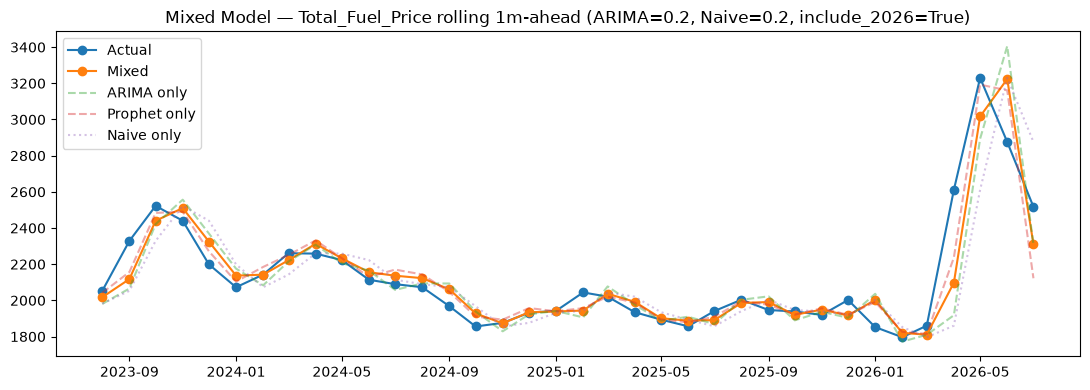

In [67]:
results = run_mixed_model(deisel_df, features_1M_diesel, ARIMA_WEIGHT=0.2, NAIVE_WEIGHT=0.2)

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
13:54:06 - cmdstanpy - INFO - Chain [1] start processing
13:54:06 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
13:54:07 - cmdstanpy - INFO - Chain [1] start processing
13:54:07 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  wa

Mixed Model — ARIMA(w=0.4) + Prophet(w=0.40) + Naive(w=0.2) | horizon=1m | include_2026=True | walk-forward steps=37
RMSE: 71.0460  |  Naive-only RMSE: 109.9339
MAE:  56.2549  |  Naive-only MAE:  79.4270
R2:   0.8524


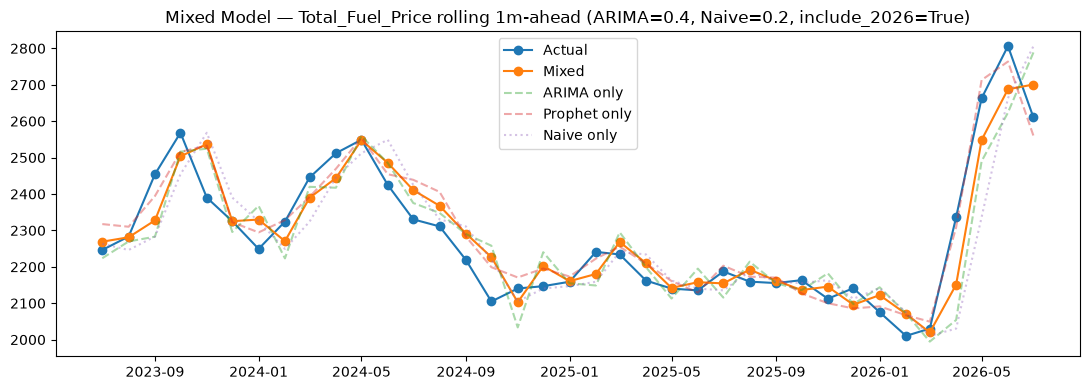

In [68]:
results = run_mixed_model(petrol_df, features_1M_petrol, FORECAST_HORIZON=1)

13:55:26 - cmdstanpy - INFO - Chain [1] start processing
13:55:26 - cmdstanpy - INFO - Chain [1] done processing
13:55:26 - cmdstanpy - INFO - Chain [1] start processing
13:55:26 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
13:55:27 - cmdstanpy - INFO - Chain [1] start processing
13:55:27 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
13:55:27 - cmdstanpy - INFO - Chain [1] start processing
13:55:27 - cmdstanpy - INFO - Chain [1] done proce

Mixed Model — ARIMA(w=0.4) + Prophet(w=0.40) + Naive(w=0.2) | horizon=2m | include_2026=True | walk-forward steps=35
RMSE: 267.0447  |  Naive-only RMSE: 338.8699
MAE:  160.6486  |  Naive-only MAE:  206.1206
R2:   0.2585


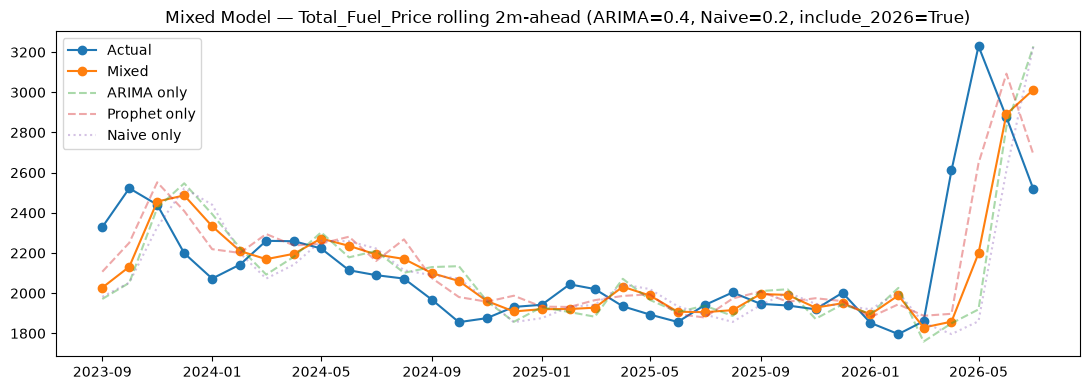

In [69]:
results = run_mixed_model(deisel_df, features_2M_diesel, FORECAST_HORIZON=2)

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
14:17:31 - cmdstanpy - INFO - Chain [1] start processing
14:17:31 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
14:17:31 - cmdstanpy - INFO - Chain [1] start processing
14:17:31 - cmdstanpy - INFO - Chain [1] done processing
14:17:31 - cmdstanpy - INFO - Chain [1] start processing
14:17:31 - cmdstanpy - INFO - Chain [1] done processing
14:17:31 - cmdstanpy - INFO - Chain [1] start processing
14:17:31 - cmdstanpy - INFO - Chain [1] done proce

Mixed Model — ARIMA(w=0.4) + Prophet(w=0.40) + Naive(w=0.2) | horizon=6m | include_2026=True | walk-forward steps=34
RMSE: 322.5231  |  Naive-only RMSE: 361.2640
MAE:  206.7194  |  Naive-only MAE:  228.4762
R2:   -0.0636


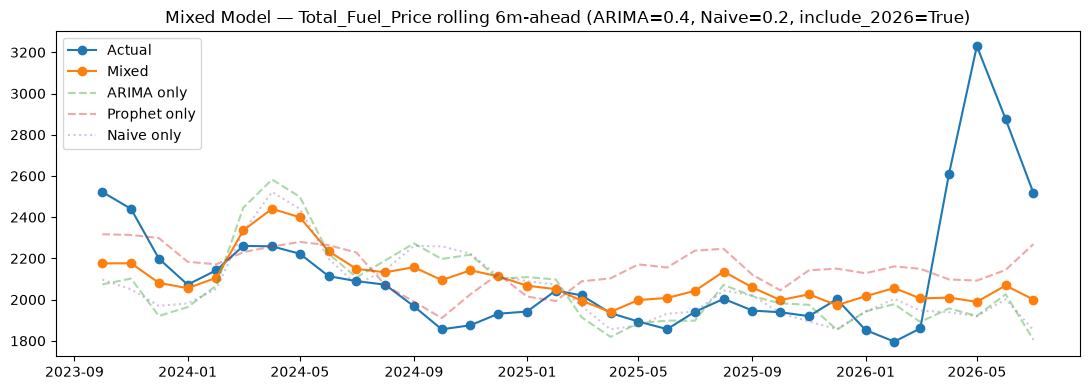

In [75]:
results = run_mixed_model(deisel_df, features_6M_diesel, FORECAST_HORIZON=6)